In [1]:
import numpy as np
import pandas as pd

In [2]:
seed1 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed1_results.tsv", sep="\t")

seed1["seed"] = [1 for i in range(len(seed1))]

In [3]:
seed2 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed2_results.tsv", sep="\t")

seed2["seed"] = [2 for i in range(len(seed2))]

In [4]:
seed3 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed3_results.tsv", sep="\t")

seed3["seed"] = [3 for i in range(len(seed3))]

In [5]:
seed4 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed4_results.tsv", sep="\t")

seed4["seed"] = [4 for i in range(len(seed4))]

In [6]:
seed5 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed5_results.tsv", sep="\t")

seed5["seed"] = [5 for i in range(len(seed5))]

In [7]:
df = pd.concat([seed1, seed2, seed3, seed4, seed5], ignore_index=True)

In [8]:
import ast

In [9]:
df['positions'] = df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [10]:
import itertools

In [11]:
# Tolerance for overlap (e.g., 30 bp window)
BIN_SIZE = 10

In [12]:
def convert_to_site_set(row):
    positions = row['positions']
    orientations = row['orientation']
    
    site_set = set()
    for (start, end), strand in zip(positions, orientations):
        center = (start + end) // 2
        binned_pos = round(center / BIN_SIZE) * BIN_SIZE
        site_set.add((binned_pos, strand))
    
    return site_set

In [13]:
# Precompute site sets per region and seed
df['site_set'] = df.apply(convert_to_site_set, axis=1)

In [14]:
df

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,...,GC_slice,GC_slice_edited,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions,seed,site_set
0,chr1,37793792,39104512,fold0,0.861165,195.0,323.0,37799936,39110656,192,...,0.459961,0.452637,0,3,54.642982,23.004061,++-,"[(1179, 1198), (2062, 2081), (1595, 1614)]",1,"{(1600, -), (1190, +), (2070, +)}"
1,chr11,65921024,67231744,fold0,0.746112,76.0,199.0,65677312,66988032,195,...,0.422852,0.445312,1,4,72.427250,23.133219,+++-,"[(1460, 1479), (1527, 1546), (2052, 2071), (15...",1,"{(2060, +), (1610, -), (1540, +), (1470, +)}"
2,chr3,38414336,39725056,fold0,0.670098,198.0,422.0,38524928,39835648,144,...,0.437988,0.442383,0,3,41.463561,20.600178,+++,"[(1484, 1503), (1766, 1785), (2086, 2105)]",1,"{(1490, +), (1780, +), (2100, +)}"
3,chr3,40978432,42289152,fold0,0.754782,82.0,182.0,40724480,42035200,206,...,0.418945,0.431152,0,3,63.560357,25.467418,+++,"[(197, 216), (890, 909), (1991, 2010)]",1,"{(2000, +), (210, +), (900, +)}"
4,chr3,51795968,53106688,fold0,0.855747,247.0,416.0,51949568,53260288,172,...,0.479492,0.576172,1,4,73.127136,23.777579,+---,"[(456, 475), (1221, 1240), (2012, 2031), (2072...",1,"{(1230, -), (2020, -), (2080, -), (460, +)}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,chr5,98777088,100087808,fold0,0.792530,198.0,311.0,98772992,100083712,200,...,0.430664,0.478516,1,1,11.613336,11.613336,+,"[(1493, 1512)]",5,"{(1500, +)}"
221,chr6,60901376,62212096,fold0,0.687477,264.0,405.0,61061120,62371840,186,...,0.367188,0.431152,0,2,25.600435,13.901901,+-,"[(2059, 2078), (883, 902)]",5,"{(2070, +), (890, -)}"
222,chr6,65816576,67127296,fold0,0.661027,56.0,182.0,65536000,66846720,193,...,0.357422,0.391602,1,2,23.364918,14.853965,--,"[(221, 240), (1153, 1172)]",5,"{(1160, -), (230, -)}"
223,chrX,46979072,48289792,fold0,0.708108,161.0,299.0,46925824,48236544,187,...,0.380859,0.424805,0,1,8.593359,8.593359,+,"[(578, 597)]",5,"{(590, +)}"


In [15]:
region_cols = ['chrom', 'centered_start', 'centered_end']
region_keys = df[region_cols].drop_duplicates().to_dict('records')

results = []

for region in region_keys:
    region_df = df[
        (df['chrom'] == region['chrom']) &
        (df['centered_start'] == region['centered_start']) &
        (df['centered_end'] == region['centered_end'])
    ]
    
    seed_to_sites = {row['seed']: row['site_set'] for _, row in region_df.iterrows()}

    for seed1, seed2 in itertools.combinations(sorted(seed_to_sites.keys()), 2):
        set1 = seed_to_sites[seed1]
        set2 = seed_to_sites[seed2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard = intersection / union if union > 0 else float('nan')
        results.append({
            **region,
            'seed1': seed1,
            'seed2': seed2,
            'jaccard': jaccard
        })

jaccard_df = pd.DataFrame(results)

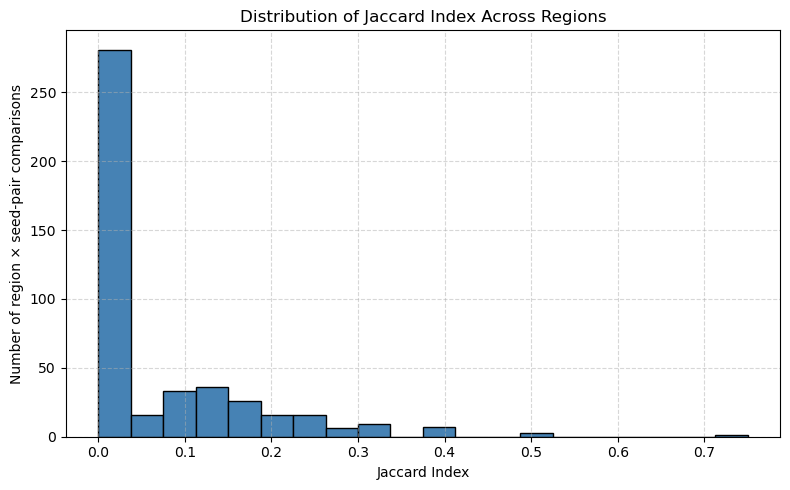

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(jaccard_df['jaccard'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Jaccard Index')
plt.ylabel('Number of region × seed-pair comparisons')
plt.title('Distribution of Jaccard Index Across Regions')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
import random

region_keys = df[['chrom', 'centered_start', 'centered_end']].drop_duplicates()
random_regions = region_keys.sample(5, random_state=42).to_dict('records')

In [18]:
def get_jaccard_matrix_from_df(region, jaccard_df):
    region_mask = (
        (jaccard_df['chrom'] == region['chrom']) &
        (jaccard_df['centered_start'] == region['centered_start']) &
        (jaccard_df['centered_end'] == region['centered_end'])
    )
    sub_df = jaccard_df[region_mask]
    seeds = sorted(set(sub_df['seed1']) | set(sub_df['seed2']))
    matrix = pd.DataFrame(np.eye(len(seeds)), index=seeds, columns=seeds)

    for _, row in sub_df.iterrows():
        s1, s2 = row['seed1'], row['seed2']
        matrix.loc[s1, s2] = row['jaccard']
        matrix.loc[s2, s1] = row['jaccard']  # symmetric

    return matrix

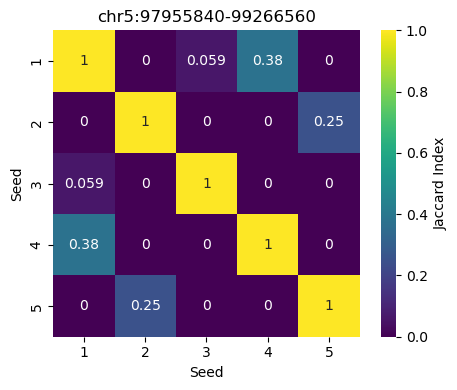

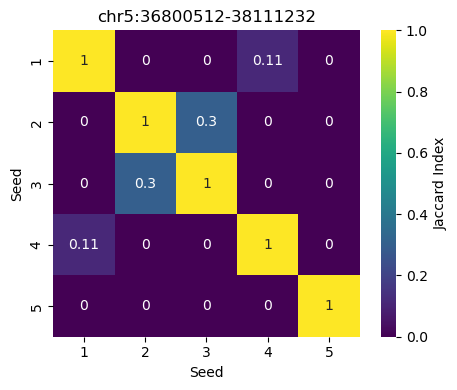

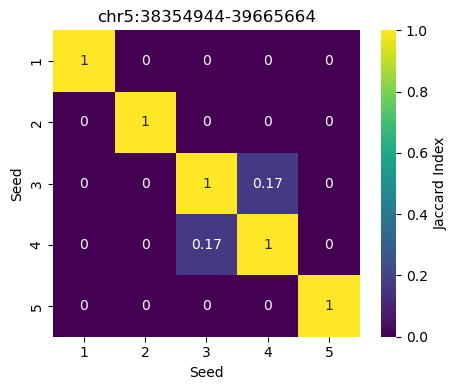

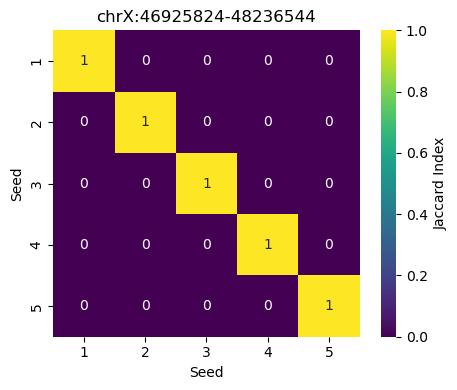

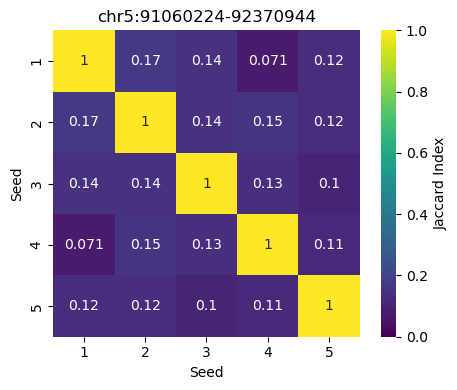

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

for region in random_regions:
    mat = get_jaccard_matrix_from_df(region, jaccard_df)

    plt.figure(figsize=(5, 4))
    sns.heatmap(mat, annot=True, cmap='viridis', vmin=0, vmax=1, square=True,
                xticklabels=mat.columns, yticklabels=mat.index,
                cbar_kws={'label': 'Jaccard Index'})
    plt.title(f"{region['chrom']}:{region['centered_start']}-{region['centered_end']}")
    plt.xlabel("Seed")
    plt.ylabel("Seed")
    plt.tight_layout()
    plt.show()

In [20]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [21]:
df['optimization_successful'] = df['SCD'] > 30

In [22]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'seed',
       'site_set', 'URQ_delta', 'optimization_successful'],
      dtype='object')

In [30]:
# collecting all CTCFs

import pandas as pd

bin_size = 2048
center_offset = 320 * bin_size
flank = 60
motif_len = 19

In [31]:
ctcf_records = []

for idx, row in df.iterrows():
    chrom = row['chrom']
    win_start = row['centered_start']
    win_end = row['centered_end']
    seed = row['seed']
    ctcf_sites = row['positions']
    orientations = list(row['orientation']) if isinstance(row['orientation'], str) else []

    if isinstance(ctcf_sites, str):
        try:
            ctcf_sites = eval(ctcf_sites)
        except:
            continue

    for i, (rel_start, rel_end) in enumerate(ctcf_sites):
        orientation = orientations[i] if i < len(orientations) else '?'
        ctcf_records.append({
            'chrom': chrom,
            'centered_start': win_start,
            'centered_end': win_end,
            'rel_start': rel_start,
            'rel_end': rel_end,
            'orientation': orientation,
            'seed': seed
        })

ctcf_df = pd.DataFrame(ctcf_records)


In [32]:
# Count number of unique seeds in which each site appears
ctcf_seed_counts = (
    ctcf_df
    .groupby(['chrom', 'centered_start', 'centered_end', 'rel_start', 'rel_end', 'orientation'])
    .agg(seeds_present=('seed', 'nunique'))
    .reset_index()
)

In [33]:
ctcf_seed_counts['fraction_across_seeds'] = ctcf_seed_counts['seeds_present'] / 5

In [34]:
ctcf_seed_counts['genomic_start'] = ctcf_seed_counts['centered_start'] + center_offset - flank + ctcf_seed_counts['rel_start']
ctcf_seed_counts['genomic_end'] = ctcf_seed_counts['centered_start'] + center_offset - flank + ctcf_seed_counts['rel_end']

In [35]:
ctcf_seed_counts

,chrom,centered_start,centered_end,rel_start,rel_end,orientation,seeds_present,fraction_across_seeds,genomic_start,genomic_end
0,chr1,37799936,39110656,149,168,+,1,0.2,38455385,38455404
1,chr1,37799936,39110656,333,352,-,1,0.2,38455569,38455588
2,chr1,37799936,39110656,398,417,+,1,0.2,38455634,38455653
3,chr1,37799936,39110656,406,425,+,1,0.2,38455642,38455661
4,chr1,37799936,39110656,467,486,-,1,0.2,38455703,38455722
...,...,...,...,...,...,...,...,...,...,...
881,chrX,48441344,49752064,1992,2011,+,1,0.2,49098636,49098655
882,chrX,48441344,49752064,2012,2031,-,1,0.2,49098656,49098675
883,chrX,48441344,49752064,2018,2037,-,1,0.2,49098662,49098681
884,chrX,48441344,49752064,2070,2089,-,1,0.2,49098714,49098733


In [36]:
from pyfaidx import Fasta

In [37]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [38]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices, dtype=int)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [39]:
def get_sequence(genome, chrom, start, end):
    seq = genome[chrom][start:end].seq.upper()
    ohe_seq = one_hot_encode_sequence(seq)
    return np.expand_dims(ohe_seq, axis=0)

In [40]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [41]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [43]:
import torch

In [44]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [45]:
from tangermeme.tools import fimo

In [47]:
ctcf_seed_counts

,chrom,centered_start,centered_end,rel_start,rel_end,orientation,seeds_present,fraction_across_seeds,genomic_start,genomic_end
0,chr1,37799936,39110656,149,168,+,1,0.2,38455385,38455404
1,chr1,37799936,39110656,333,352,-,1,0.2,38455569,38455588
2,chr1,37799936,39110656,398,417,+,1,0.2,38455634,38455653
3,chr1,37799936,39110656,406,425,+,1,0.2,38455642,38455661
4,chr1,37799936,39110656,467,486,-,1,0.2,38455703,38455722
...,...,...,...,...,...,...,...,...,...,...
881,chrX,48441344,49752064,1992,2011,+,1,0.2,49098636,49098655
882,chrX,48441344,49752064,2012,2031,-,1,0.2,49098656,49098675
883,chrX,48441344,49752064,2018,2037,-,1,0.2,49098662,49098681
884,chrX,48441344,49752064,2070,2089,-,1,0.2,49098714,49098733


In [96]:
all_hits = []
padding = 10

for idx, row in ctcf_seed_counts.iterrows():
    chrom = row["chrom"]
    site_start = row["genomic_start"]
    site_end = row["genomic_end"]
    site_orient = row["orientation"]
    seeds_frac = row["fraction_across_seeds"]
    
    sequence = get_sequence(genome, chrom, site_start-padding, site_end+padding)
    
    hits = fimo.fimo(
        motifs=motifs_dict,
        sequences=sequence,
        threshold=0.1,
        reverse_complement=True
    )[0]
    
    # Only add non-empty results
    if not hits.empty:
        hits["chrom"] = chrom
        hits["start"] = site_start
        hits["end"] = site_end
        hits["orientation"] = site_orient
        hits["fraction_across_seeds"] = seeds_frac
        all_hits.append(hits)

In [97]:
combined_hits_df = pd.concat(all_hits, ignore_index=True)

In [98]:
hits_same_orient = combined_hits_df[combined_hits_df["strand"] == combined_hits_df["orientation"]]

In [99]:
hits_same_orient

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value,chrom,orientation,fraction_across_seeds
0,CTCF,0,0,38455385,38455404,+,-5.878875,0.009831,chr1,+,0.2
1,CTCF,0,0,38455385,38455404,+,-7.684104,0.015017,chr1,+,0.2
2,CTCF,0,0,38455385,38455404,+,-13.691509,0.050796,chr1,+,0.2
8,CTCF,0,0,38455569,38455588,-,-16.234408,0.079224,chr1,-,0.2
9,CTCF,0,0,38455569,38455588,-,-4.092738,0.006248,chr1,-,0.2
...,...,...,...,...,...,...,...,...,...,...,...
3735,CTCF,0,0,49098662,49098681,-,-12.681351,0.042268,chrX,-,0.2
3736,CTCF,0,0,49098662,49098681,-,-10.429977,0.027473,chrX,-,0.2
3737,CTCF,0,0,49098662,49098681,-,-6.824094,0.012484,chrX,-,0.2
3744,CTCF,0,0,49098714,49098733,-,-15.891574,0.074215,chrX,-,0.2


/tmp/SLURM_1127400/ipykernel_1736102/3774218930.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hits_same_orient["log10_pvalue"] = -np.log10(hits_same_orient["p-value"])
/tmp/SLURM_1127400/ipykernel_1736102/3774218930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


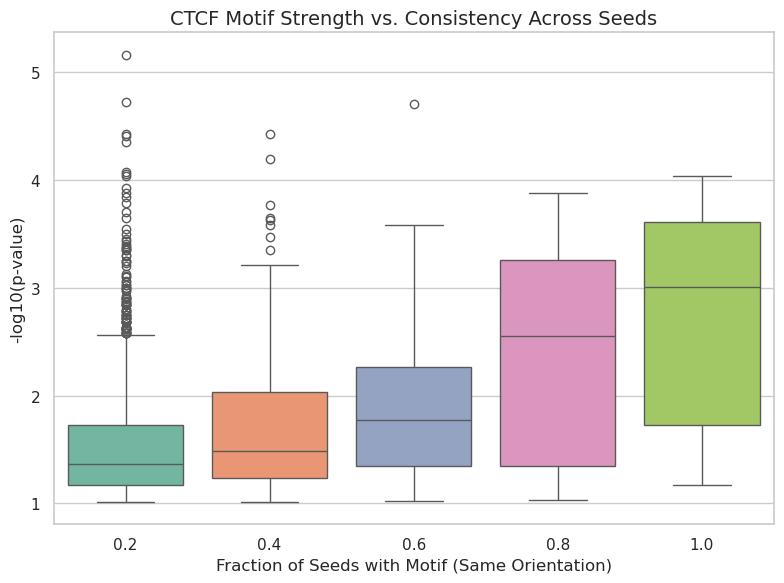

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Optional: log-transform the p-values
hits_same_orient["log10_pvalue"] = -np.log10(hits_same_orient["p-value"])

# Set plot style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=hits_same_orient,
    x="fraction_across_seeds",
    y="log10_pvalue",
    palette="Set2"
)

plt.xlabel("Fraction of Seeds with Motif (Same Orientation)", fontsize=12)
plt.ylabel("-log10(p-value)", fontsize=12)
plt.title("CTCF Motif Strength vs. Consistency Across Seeds", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

In [ ]:
# Pivot to align seed 1 and seed 2 by region
pivot_df = df[df['seed'].isin([1, 2])].pivot_table(
    index=['chrom', 'start', 'end'], 
    columns='seed', 
    values='URQ_result'
).dropna()

pivot_df.columns = ['seed1', 'seed2']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed1'], pivot_df['seed2'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed1'], pivot_df['seed2'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_result (seed 1)')
plt.ylabel('URQ_result (seed 2)')
plt.title(f'URQ_result Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Pivot to align seed 1 and seed 2 by region
pivot_df = df[df['seed'].isin([1, 2])].pivot_table(
    index=['chrom', 'start', 'end'], 
    columns='seed', 
    values='URQ_delta'
).dropna()

pivot_df.columns = ['seed1', 'seed2']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed1'], pivot_df['seed2'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed1'], pivot_df['seed2'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_delta (seed 1)')
plt.ylabel('URQ_delta (seed 2)')
plt.title(f'URQ_delta Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
region_cols = ['chrom', 'centered_start', 'centered_end']
aligned_df = df.pivot_table(index=region_cols, columns='seed', values=['orientation', 'positions'], aggfunc='first')
aligned_df = aligned_df.dropna()  # keep only complete pairs

In [ ]:
def compute_matching_motifs(positions1, orientations1, positions2, orientations2):
    count = 0
    for i, (pos1, ori1) in enumerate(zip(positions1, orientations1)):
        for j, (pos2, ori2) in enumerate(zip(positions2, orientations2)):
            # Same orientation
            if ori1 != ori2:
                continue

            # Compute overlap
            start1, end1 = pos1
            start2, end2 = pos2

            overlap_start = max(start1, start2)
            overlap_end = min(end1, end2)
            overlap = max(0, overlap_end - overlap_start)

            motif_len1 = end1 - start1
            motif_len2 = end2 - start2
            min_motif_len = min(motif_len1, motif_len2)

            if overlap / min_motif_len > 0.5:
                count += 1
                break  # Don't double-count motif1
    return count


In [ ]:
matching_counts = []

for idx, row in aligned_df.iterrows():
    pos1 = row[('positions', 1)]
    pos2 = row[('positions', 2)]
    ori1 = row[('orientation', 1)]
    ori2 = row[('orientation', 2)]

    if len(pos1) != len(ori1) or len(pos2) != len(ori2):
        continue  # skip malformed rows

    match = compute_matching_motifs(pos1, ori1, pos2, ori2)
    total = max(len(pos1), len(pos2))

    matching_counts.append({
        'chrom': idx[0],
        'centered_start': idx[1],
        'centered_end': idx[2],
        'matching_ctcfs': match,
        'max_ctcfs': total,
        'fraction_matched': match / total
    })

matching_df = pd.DataFrame(matching_counts)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.hist(matching_df['fraction_matched'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Fraction of CTCF Motifs Matched Between Seeds')
plt.ylabel('Number of Regions')
plt.title('CTCF Design Similarity Between Seeds')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# aligned_df

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, Patch
import ast

# --- Choose a region ---
region = ('chr1', 37799936, 39110656)  # replace with actual centered region
region_df = df[
    (df['chrom'] == region[0]) &
    (df['centered_start'] == region[1]) &
    (df['centered_end'] == region[2]) &
    (df['seed'].isin([1, 2, 3, 4, 5]))
]

# --- Parse positions if needed ---
region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(12, 4))  # taller for more rows
seed_order = [5, 4, 3, 2, 1]
y_positions = {seed: idx for idx, seed in enumerate(seed_order)}  # top-down: 5 → 0

# --- Draw motifs ---
for _, row in region_df.iterrows():
    seed = row['seed']
    y = y_positions[seed]
    positions = row['positions']
    orientations = row['orientation']
    
    for (start, end), ori in zip(positions, orientations):
        color = 'blue' if ori == '+' else 'red'
        direction = 1 if ori == '+' else -1
        width = end - start
        arrow = FancyArrow(start, y, width * direction, 0,
                           width=0.2,
                           head_width=0.3,
                           head_length=min(20, width * 0.6),
                           length_includes_head=True,
                           color=color)
        ax.add_patch(arrow)

# --- Axis settings ---
ax.set_xlim(0, 2168)
ax.set_ylim(-1, len(seed_order))
ax.set_yticks([y_positions[s] for s in seed_order])
ax.set_yticklabels([f'Seed {s}' for s in seed_order])
ax.set_xlabel('Relative Position (bp)')
ax.set_title(f"CTCF Motif Orientation in 2048bp Slice – {region[0]}:{region[1]}-{region[2]}")
ax.grid(axis='x', linestyle='--', alpha=0.4)

# --- Legend ---
legend_handles = [
    Patch(color='blue', label='Orientation +'),
    Patch(color='red', label='Orientation -')
]
ax.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# --- Convert to dict: seed → list of (start, end, orientation) ---
motifs_by_seed = {}
for _, row in region_df.iterrows():
    motifs_by_seed[row['seed']] = [
        (start, end, ori)
        for (start, end), ori in zip(row['positions'], row['orientation'])
    ]

In [ ]:
def motifs_match(m1, m2):
    start1, end1, ori1 = m1
    start2, end2, ori2 = m2

    if ori1 != ori2:
        return False

    overlap_start = max(start1, start2)
    overlap_end = min(end1, end2)
    overlap = max(0, overlap_end - overlap_start)

    len1 = end1 - start1
    len2 = end2 - start2
    min_len = min(len1, len2)

    return overlap / min_len > 0.5

In [ ]:
from itertools import combinations

In [ ]:
from collections import defaultdict

# Store matches like: (seed1, idx1) → list of (seed2, idx2)
matches = defaultdict(list)

for seed_a, seed_b in combinations(motifs_by_seed.keys(), 2):
    motifs_a = motifs_by_seed[seed_a]
    motifs_b = motifs_by_seed[seed_b]

    for i, m1 in enumerate(motifs_a):
        for j, m2 in enumerate(motifs_b):
            if motifs_match(m1, m2):
                matches[(seed_a, i)].append((seed_b, j))
                matches[(seed_b, j)].append((seed_a, i))  # symmetric


In [ ]:
for key in sorted(matches.keys()):
    seed, idx = key
    m1 = motifs_by_seed[seed][idx]
    print(f"Motif {idx} from seed {seed} ({m1[2]} {m1[0]}-{m1[1]}) matches with:")
    for match_seed, match_idx in matches[key]:
        m2 = motifs_by_seed[match_seed][match_idx]
        print(f"   ↳ Seed {match_seed}, motif {match_idx} ({m2[2]} {m2[0]}-{m2[1]})")

In [ ]:
central_bin = 256
cropping = 64
bins_size = 2048
flanks = 60

In [ ]:
chrom = "chr1"
start = 37799936
end = 39110656

In [ ]:
path_to_ohe_seq = f"/scratch1/smaruj/genomic_insertion_loci/ohe_X/fold0/{chrom}_{start}_{end}_X.pt"

In [ ]:
import torch

In [ ]:
ohe = torch.load(path_to_ohe_seq)

In [ ]:
scanned_slice_start = ((central_bin + cropping) * bins_size) - flanks

In [ ]:
scanned_slice_end = ((central_bin + cropping + 1) * bins_size) + flanks

In [ ]:
ohe.shape

In [ ]:
ohe_slice = ohe[:, :, scanned_slice_start:scanned_slice_end]

In [ ]:
# check_for_ctcf = ohe_slice[0, :, 1661:1680]
check_for_ctcf = ohe_slice[0, :, 1595:1614]

check_for_ctcf_np = check_for_ctcf.numpy()

In [ ]:
check_for_ctcf_np

In [ ]:
def decode_ohe_dna(ohe_array, reverse_complement=False):
    """
    Decode a one-hot encoded DNA array (shape: 4 x seq_len) into a string.
    If reverse_complement=True, returns the reverse complement of the sequence.
    """
    # Map from channel index to base
    index_to_base = ['A', 'C', 'G', 'T']
    
    # Decode from one-hot
    base_indices = np.argmax(ohe_array, axis=0)
    sequence = ''.join(index_to_base[i] for i in base_indices)
    
    if reverse_complement:
        # Define complement map
        complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
        sequence = ''.join(complement[base] for base in reversed(sequence))
    
    return sequence

In [ ]:
decoded = decode_ohe_dna(check_for_ctcf_np, reverse_complement=True)

In [ ]:
decoded_sequence = ''.join(decoded)
print(decoded_sequence)